In [1]:
print("Hello team, this is Bhanu ")

Hello team, this is Bhanu


In [8]:
##1. What is the average age of Female athletes who participated in this graded exercise tests?
import pandas as pd

# Load the subject-info CSV
subject_info = pd.read_csv("subject-info.csv")  

# Filter for female athletes (Sex == 0)
female_athletes = subject_info[subject_info['Sex'] == 1]

# Calculate the average age
average_age_female = female_athletes['Age'].mean()

# Print the result
print("Average age of female athletes:", average_age_female)

Average age of female athletes: 26.044966442953022


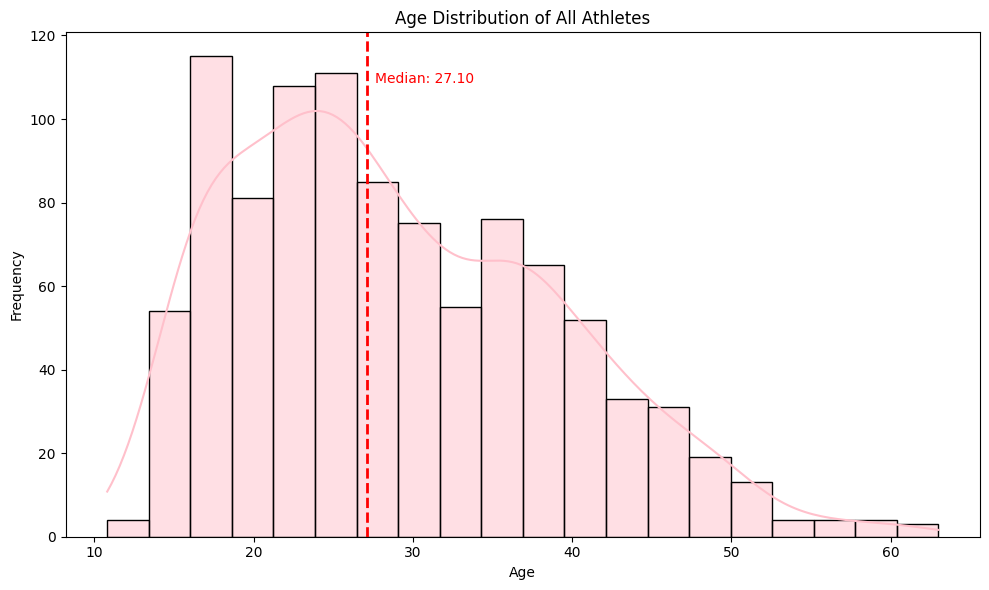

In [15]:
##2. Visualize age distribution of all athletes and display the median value in the chart.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
subject_info = pd.read_csv("subject-info.csv")  
# Calculate the median age
median_age = subject_info['Age'].median()

# Plot the age distribution
plt.figure(figsize=(10, 6))
sns.histplot(subject_info['Age'], kde=True, bins=20, color='pink')

# Add a vertical line for the median
plt.axvline(median_age, color='red', linestyle='--', linewidth=2)
plt.text(median_age + 0.5, plt.ylim()[1] * 0.9, f'Median: {median_age:.2f}', color='red')

# Add titles and labels
plt.title('Age Distribution of All Athletes')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()

# Show the plot
plt.show()



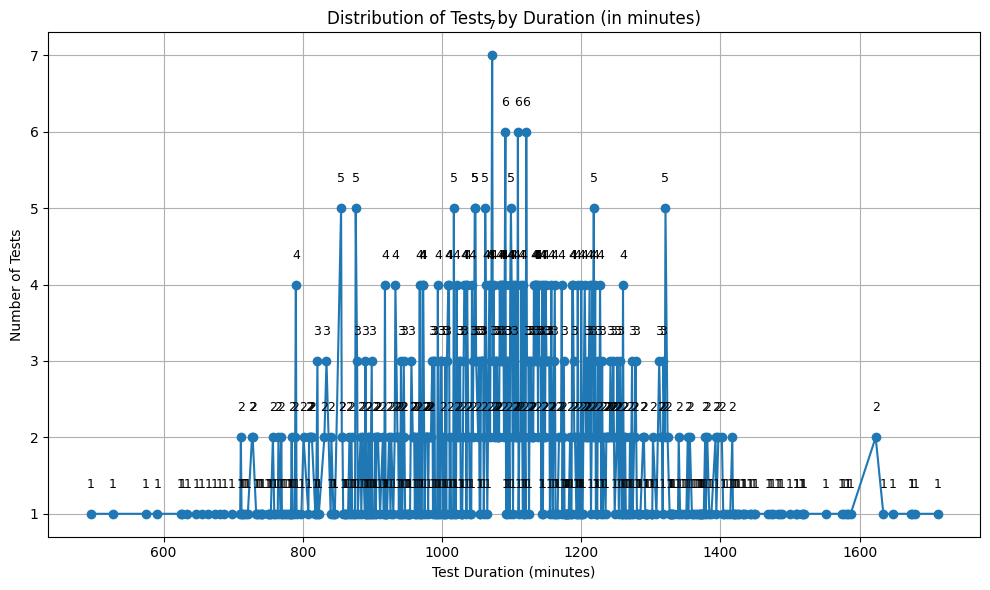

In [13]:
###3.Find the maximum time taken for all tests and then visualize the distribution of number of tests based on the test duration in minutes. 
##Use a line chart and display the count of tests in the chart as well.
import pandas as pd
import matplotlib.pyplot as plt

# Load the test_measure data
test_measure = pd.read_csv("test_measure.csv")  

# Calculate the max time (duration) for each test
test_durations = test_measure.groupby('ID_test')['time'].max()

# Count the number of tests for each duration
duration_counts = test_durations.value_counts().sort_index()

# Plot the distribution as a line chart
plt.figure(figsize=(10, 6))
plt.plot(duration_counts.index, duration_counts.values, marker='o', linestyle='-')
plt.title('Distribution of Tests by Duration (in minutes)')
plt.xlabel('Test Duration (minutes)')
plt.ylabel('Number of Tests')

# Annotate the counts on the chart
for x, y in zip(duration_counts.index, duration_counts.values):
    plt.text(x, y + 0.3, str(y), ha='center', va='bottom', fontsize=9)

plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
##4.Display the consolidated list of overweight or obese people based on their BMI.
import pandas as pd

# Load the subject-info data
subject_info = pd.read_csv("subject-info.csv")  

# Convert height from cm to meters
subject_info['Height_m'] = subject_info['Height'] / 100

# Calculate BMI
subject_info['BMI'] = subject_info['Weight'] / (subject_info['Height_m'] ** 2)

# Classify BMI categories
def classify_bmi(bmi):
    if bmi >= 30:
        return 'Obese'
    elif bmi >= 25:
        return 'Overweight'
    else:
        return 'Normal'

subject_info['BMI_Category'] = subject_info['BMI'].apply(classify_bmi)

# Filter only overweight or obese
overweight_obese = subject_info[subject_info['BMI_Category'].isin(['Overweight', 'Obese'])]

# Display the result
print(overweight_obese[['ID', 'Age', 'Weight', 'Height', 'BMI', 'BMI_Category']])


      ID   Age  Weight  Height        BMI BMI_Category
34   134  14.7    76.0   173.0  25.393431   Overweight
40   588  14.9    83.0   182.0  25.057360   Overweight
41    40  15.0    77.0   165.0  28.282828   Overweight
48   590  15.6    88.7   178.0  27.995203   Overweight
54   313  15.9    68.0   158.0  27.239224   Overweight
..   ...   ...     ...     ...        ...          ...
982  597  55.4    78.0   175.6  25.295635   Overweight
985  755  58.5    64.0   157.0  25.964542   Overweight
989  390  61.3   102.0   185.0  29.802776   Overweight
990  596  61.6    74.0   169.0  25.909457   Overweight
991  296  63.0    83.5   171.5  28.389532   Overweight

[294 rows x 6 columns]


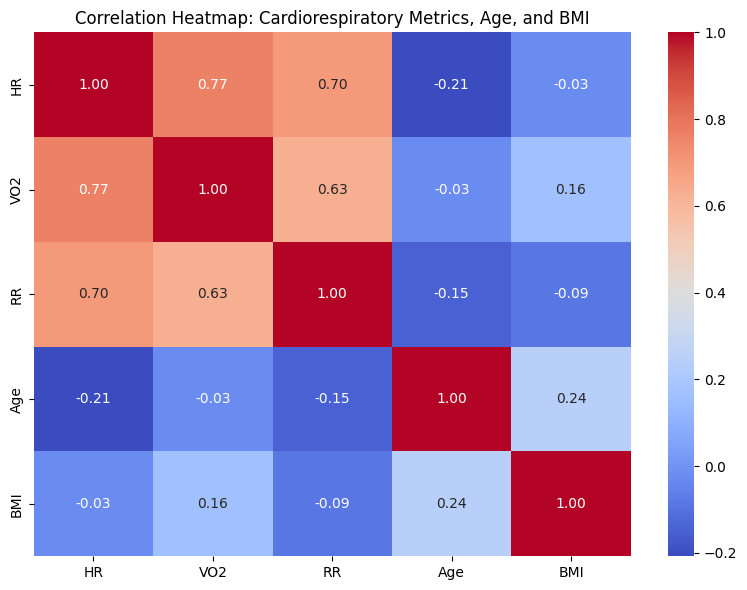

In [16]:
###5. Create a heatmap to visualize the correlations among any three cardiorespiratory measurements, Age, and BMI.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
subject_info = pd.read_csv("subject-info.csv")
test_measure = pd.read_csv("test_measure.csv")

# Calculate BMI
subject_info['Height_m'] = subject_info['Height'] / 100
subject_info['BMI'] = subject_info['Weight'] / (subject_info['Height_m'] ** 2)

# Merge both datasets on 'ID'
merged = pd.merge(test_measure, subject_info[['ID', 'Age', 'BMI']], on='ID')

# Select relevant columns
data = merged[['HR', 'VO2', 'RR', 'Age', 'BMI']]

# Compute correlation matrix
corr = data.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Cardiorespiratory Metrics, Age, and BMI")
plt.tight_layout()
plt.show()

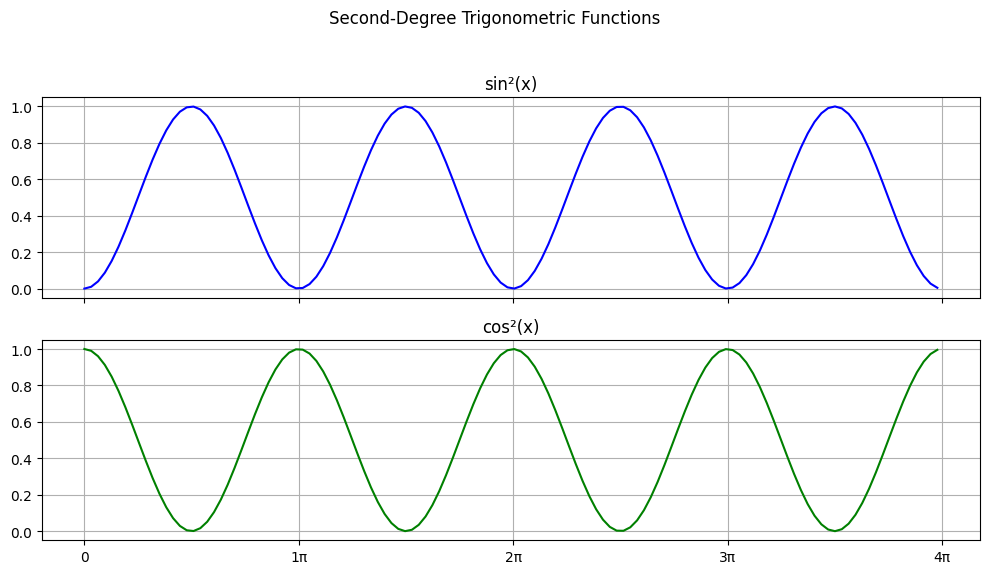

In [17]:
###6.Generate subplots for second-degree trigonometric functions,using x=np.arange(0,4*np.pi,0.1) in object oriented approach.
 ###Label every π interval on X axis.
import numpy as np
import matplotlib.pyplot as plt

# Create x values
x = np.arange(0, 4 * np.pi, 0.1)

# Calculate second-degree trigonometric functions
y1 = np.sin(x) ** 2
y2 = np.cos(x) ** 2

# Create figure and axes using object-oriented approach
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot sin²(x)
ax1.plot(x, y1, color='blue')
ax1.set_title('sin²(x)')
ax1.grid(True)

# Plot cos²(x)
ax2.plot(x, y2, color='green')
ax2.set_title('cos²(x)')
ax2.grid(True)

# Set x-ticks at every π interval
pi_ticks = np.arange(0, 4 * np.pi + 0.1, np.pi)
pi_labels = [f'{int(i)}π' if i > 0 else '0' for i in range(5)]
ax2.set_xticks(pi_ticks)
ax2.set_xticklabels(pi_labels)

# Set labels
fig.suptitle('Second-Degree Trigonometric Functions')
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show plot
plt.show()

In [ ]:
##7. Get a number from the user and print its multiplication table from 1 to 10.

# Get input from the user
num = int(input("Enter a number: "))

# Print multiplication table
print(f"\nMultiplication Table for {num}:\n")
for i in range(1, 11):
    print(f"{num} x {i} = {num * i}")


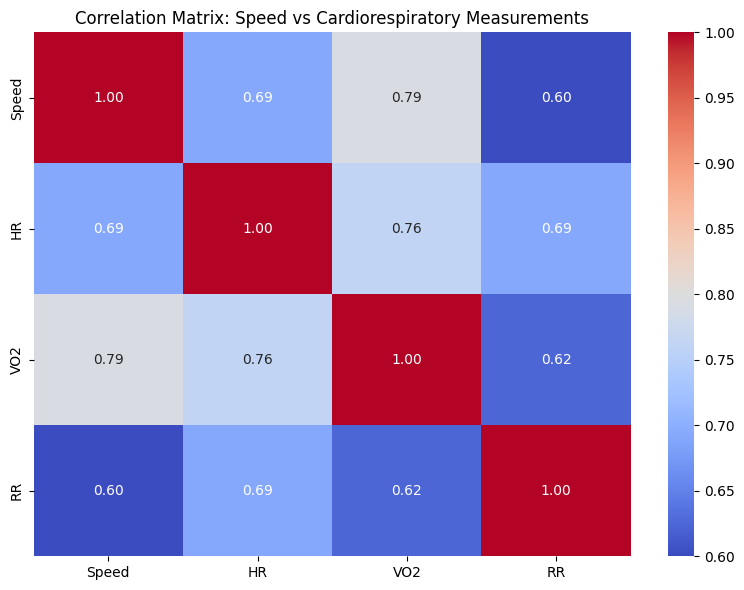

In [ ]:
##8.Write a function to display a correlation matrix between speed of the treadmill and any cardiorespiratory measurement  of the athelete.
##(Exclude warmup period).


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def show_correlation_matrix(file_path="test_measure.csv", measurements=None):
    """
    Displays a correlation matrix between Speed and selected cardiorespiratory measurements,
    excluding the warmup period (time == 0).
    
    Parameters:
    - file_path: str, path to the CSV file
    - measurements: list of str, cardiorespiratory measurement columns to include (e.g., ['HR', 'VO2'])
    """
    if measurements is None:
        measurements = ['HR', 'VO2', 'RR', 'VCO2', 'VE']  # Default measurements

    # Load the dataset
    df = pd.read_csv(file_path)

    # Exclude warmup period
    df = df[df['time'] > 0]

    # Select Speed and desired measurements
    selected_cols = ['Speed'] + [m for m in measurements if m in df.columns]
    data = df[selected_cols]

    # Compute correlation
    corr = data.corr()

    # Plot the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix: Speed vs Cardiorespiratory Measurements')
    plt.tight_layout()
    plt.show()


show_correlation_matrix("test_measure.csv", measurements=['HR', 'VO2', 'RR'])

In [ ]:
##9. What percentage of athletes exceeded 90% of max HR after warm up period? 

import pandas as pd

# Load the datasets
subject_info = pd.read_csv("subject-info.csv")
test_measure = pd.read_csv("test_measure.csv")

# Remove warmup period
test_measure = test_measure[test_measure['time'] > 0]

# Merge data on athlete ID
merged = pd.merge(test_measure, subject_info[['ID', 'Age']], on='ID')

# Calculate 90% of max HR for each athlete
merged['Max_HR'] = 220 - merged['Age']
merged['HR_90_percent'] = 0.9 * merged['Max_HR']

# Check if any HR exceeds 90% max for each athlete
athletes_exceeded = merged[merged['HR'] > merged['HR_90_percent']]['ID'].unique()

# Total unique athletes
total_athletes = subject_info['ID'].nunique()

# Calculate percentage
percentage_exceeded = (len(athletes_exceeded) / total_athletes) * 100

print(f"{percentage_exceeded:.2f}% of athletes exceeded 90% of their max HR after the warmup period.")


95.80% of athletes exceeded 90% of their max HR after the warmup period.


In [27]:
####10.Which athlete spent the longest  time period in this exercise program to complete all of their cardiorespiratory measurements
##(including the time interval between different test cases)?
import pandas as pd

# Load test data
test_measure = pd.read_csv("test_measure.csv")

# Extract athlete ID from 'ID_test' (e.g., "1021_1" → 1021)
test_measure['ID'] = test_measure['ID_test'].apply(lambda x: int(str(x).split('_')[0]))

# Get the max time per test
max_time_per_test = test_measure.groupby('ID_test')['time'].max().reset_index()

# Extract athlete ID again
max_time_per_test['ID'] = max_time_per_test['ID_test'].apply(lambda x: int(str(x).split('_')[0]))

# Sum time across all tests for each athlete
total_time_per_athlete = max_time_per_test.groupby('ID')['time'].sum().reset_index()

# Identify the athlete with the longest total time
longest_athlete = total_time_per_athlete.loc[total_time_per_athlete['time'].idxmax()]

# Display the result
print(f"Athlete ID: {longest_athlete['ID']}")
print(f"Total Time Spent: {longest_athlete['time']} minutes")



Athlete ID: 506
Total Time Spent: 6017 minutes


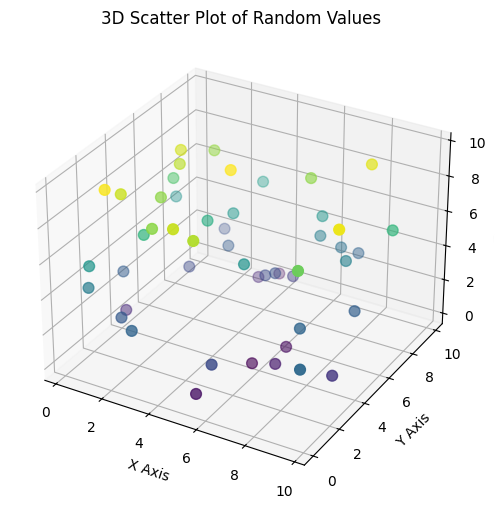

In [28]:
##11.Plot a 3-D graph using any set of random values chosen by you

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate random values
np.random.seed(42)
x = np.random.rand(50) * 10
y = np.random.rand(50) * 10
z = np.random.rand(50) * 10

# Create 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(x, y, z, c=z, cmap='viridis', marker='o', s=60)

# Axis labels
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Scatter Plot of Random Values')

plt.show()